In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("fact_disease_surveillance_cleaned.csv")

In [7]:
df[['disease_id', 'state_id', 'public_health_risk_score', 'total_reported_cases']].head()

,disease_id,state_id,public_health_risk_score,total_reported_cases
0,1,1,31.3,2091
1,2,1,32.1,2357
2,3,1,32.3,2936
3,4,1,10.0,335
4,5,1,2.9,310


In [8]:
disease_risk = df.groupby('disease_id')['public_health_risk_score'].mean().sort_values(ascending=False)

disease_risk

disease_id
4     17.307812
5     17.126042
6     16.966406
2     16.823785
7     16.561545
8     16.389323
3     16.288281
1     16.177778
12    16.046267
11    15.754080
9     15.070660
10    14.726476
Name: public_health_risk_score, dtype: float64

In [9]:
top_5_diseases = disease_risk.head(5)

top_5_diseases

disease_id
4    17.307812
5    17.126042
6    16.966406
2    16.823785
7    16.561545
Name: public_health_risk_score, dtype: float64

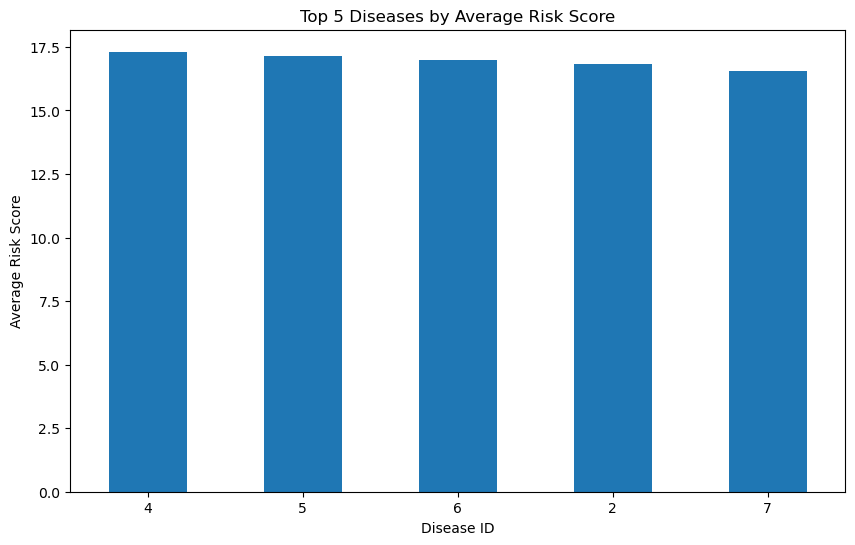

In [10]:
plt.figure(figsize=(10,6))

top_5_diseases.plot(kind='bar')

plt.title('Top 5 Diseases by Average Risk Score')
plt.xlabel('Disease ID')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=0)

plt.show()

In [11]:
state_risk = df.groupby('state_id')['public_health_risk_score'].mean().sort_values(ascending=False)

state_risk

state_id
1     18.703704
14    18.533796
24    18.494907
27    18.413657
11    18.263194
7     18.209722
23    18.168750
19    18.091667
3     17.952778
21    17.950000
20    17.948843
4     17.880093
30    17.874537
10    17.660648
28    17.633102
26    17.563426
12    17.426852
29    17.313657
13    17.312269
8     17.260417
5     17.255556
9     16.953472
25    16.211806
16    15.843981
15    15.135417
18    14.364352
32    13.565972
2     13.464120
17    13.423148
6     13.228472
22     8.643056
31     3.890509
Name: public_health_risk_score, dtype: float64

In [12]:
top_5_states = state_risk.head(5)

top_5_states

state_id
1     18.703704
14    18.533796
24    18.494907
27    18.413657
11    18.263194
Name: public_health_risk_score, dtype: float64

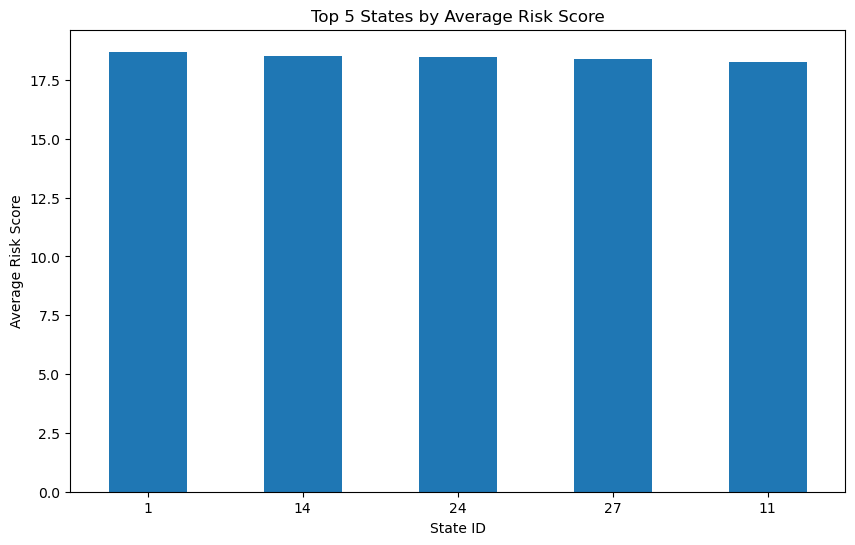

In [13]:
plt.figure(figsize=(10,6))

top_5_states.plot(kind='bar')

plt.title('Top 5 States by Average Risk Score')
plt.xlabel('State ID')
plt.ylabel('Average Risk Score')
plt.xticks(rotation=0)

plt.show()

In [14]:
correlation = df['public_health_risk_score'].corr(df['total_reported_cases'])

print("Correlation:", correlation)

Correlation: 0.48502273615597913


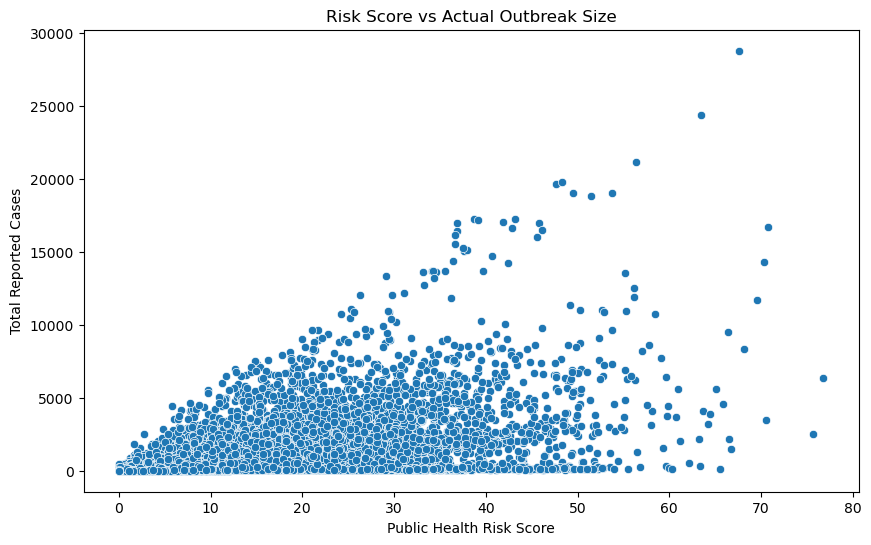

In [15]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='public_health_risk_score',
    y='total_reported_cases'
)

plt.title('Risk Score vs Actual Outbreak Size')
plt.xlabel('Public Health Risk Score')
plt.ylabel('Total Reported Cases')

plt.show()

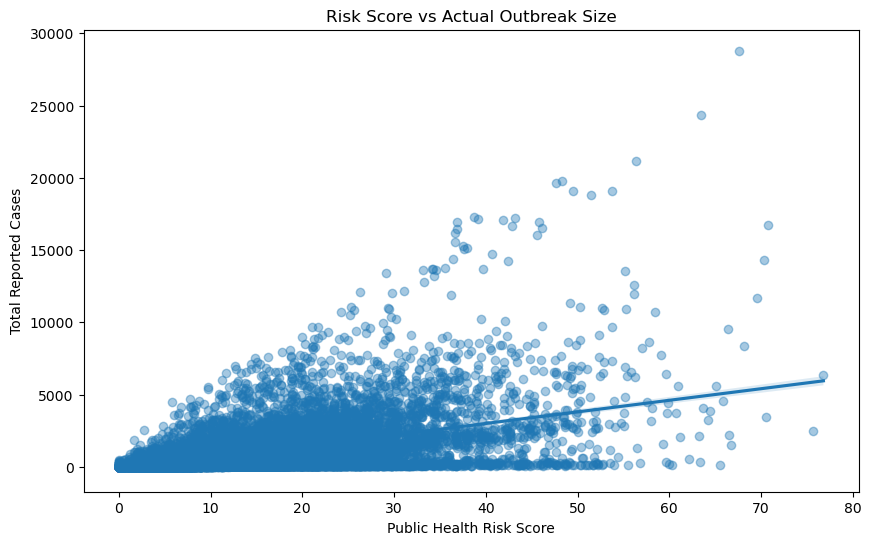

In [16]:
plt.figure(figsize=(10,6))

sns.regplot(
    data=df,
    x='public_health_risk_score',
    y='total_reported_cases',
    scatter_kws={'alpha': 0.4}
)

plt.title('Risk Score vs Actual Outbreak Size')
plt.xlabel('Public Health Risk Score')
plt.ylabel('Total Reported Cases')

plt.show()

In [17]:
heatmap_data = df.pivot_table(
    index='state_id',
    columns='disease_id',
    values='public_health_risk_score',
    aggfunc='mean'
)

heatmap_data

disease_id,1,2,3,4,5,6,7,8,9,10,11,12
state_id,,,,,,,,,,,,
1,20.430556,20.683333,16.933333,21.666667,16.852778,17.766667,20.016667,17.491667,17.902778,15.916667,18.627778,20.155556
2,11.861111,13.288889,16.483333,16.016667,12.736111,14.288889,14.269444,12.083333,11.369444,11.555556,13.247222,14.369444
3,16.638889,18.038889,16.794444,19.380556,18.530556,19.600000,20.652778,18.138889,16.580556,15.877778,16.861111,18.338889
4,17.333333,20.311111,16.694444,17.691667,17.775000,18.272222,18.247222,17.855556,16.305556,15.311111,17.466667,21.297222
5,18.888889,16.772222,16.472222,18.680556,18.244444,17.908333,16.022222,17.688889,13.880556,16.863889,18.852778,16.791667
6,13.875000,13.052778,10.769444,12.958333,13.766667,14.805556,16.555556,14.602778,11.908333,12.500000,10.205556,13.741667
7,17.822222,20.058333,17.633333,18.066667,20.213889,19.613889,19.988889,17.616667,14.755556,18.177778,17.055556,17.513889
8,17.286111,16.022222,16.247222,18.211111,16.758333,20.338889,15.919444,17.894444,16.077778,17.544444,17.644444,17.180556
9,16.000000,17.866667,15.930556,18.163889,19.666667,16.911111,16.197222,17.925000,14.819444,15.950000,17.675000,16.336111


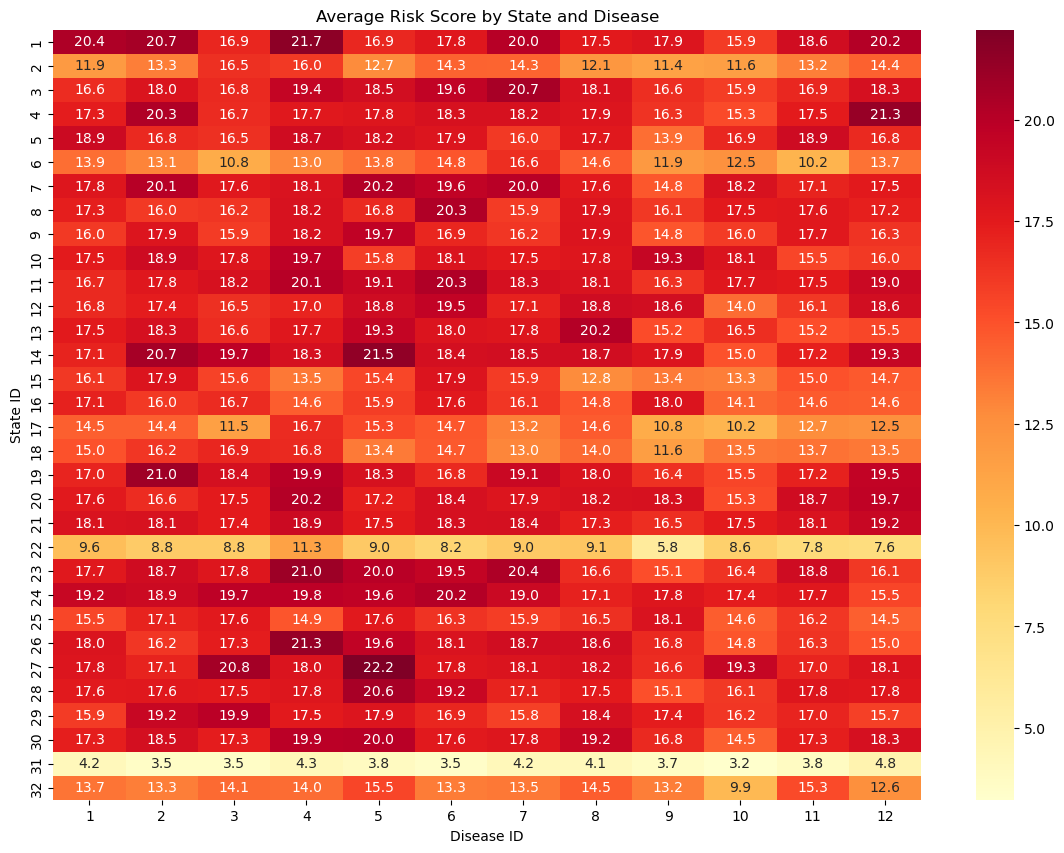

In [18]:
plt.figure(figsize=(14,10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd'
)

plt.title('Average Risk Score by State and Disease')
plt.xlabel('Disease ID')
plt.ylabel('State ID')

plt.show()

In [19]:
highest_combinations = heatmap_data.stack().sort_values(ascending=False)

highest_combinations.head(10)

state_id  disease_id
27        5             22.222222
1         4             21.666667
14        5             21.536111
4         12            21.297222
26        4             21.280556
23        4             21.047222
19        2             21.008333
27        3             20.766667
14        2             20.688889
1         2             20.683333
dtype: float64

In [20]:
df[
    ['disease_id', 'state_id', 'public_health_risk_score', 'total_reported_cases']
].sort_values(
    by='public_health_risk_score',
    ascending=False
).head(10)

,disease_id,state_id,public_health_risk_score,total_reported_cases
12123,4,19,76.8,6350
11836,5,27,75.7,2498
7072,5,14,70.8,16707
11607,4,8,70.5,3448
2849,6,14,70.3,14321
11667,4,13,69.6,11699
2381,6,7,68.1,8370
3760,5,26,67.6,28799
12639,4,30,66.7,1491
8380,5,27,66.5,2200


In [21]:
df[
    ['disease_id', 'state_id', 'total_reported_cases', 'public_health_risk_score']
].sort_values(
    by='total_reported_cases',
    ascending=False
).head(10)

,disease_id,state_id,total_reported_cases,public_health_risk_score
3760,5,26,28799,67.6
3375,4,26,24365,63.5
2991,4,26,21169,56.4
13356,1,26,19781,48.3
7599,4,26,19648,47.6
3376,5,26,19074,53.7
3761,6,26,19064,49.5
6834,7,26,18809,51.5
12209,6,26,17269,38.7
2607,4,26,17242,43.2


In [23]:
print("EDA RESULTS")

print("\nTop 5 Diseases by Average Risk Score:")
print(disease_risk.head(5))

print("\nTop 5 States by Average Risk Score:")
print(state_risk.head(5))

print("\nCorrelation between Risk Score and Actual Outbreak Size:")
print(round(correlation, 3))

print("\nTop 10 State-Disease Risk Combinations:")
print(highest_combinations.head(10))

EDA RESULTS

Top 5 Diseases by Average Risk Score:
disease_id
4    17.307812
5    17.126042
6    16.966406
2    16.823785
7    16.561545
Name: public_health_risk_score, dtype: float64

Top 5 States by Average Risk Score:
state_id
1     18.703704
14    18.533796
24    18.494907
27    18.413657
11    18.263194
Name: public_health_risk_score, dtype: float64

Correlation between Risk Score and Actual Outbreak Size:
0.485

Top 10 State-Disease Risk Combinations:
state_id  disease_id
27        5             22.222222
1         4             21.666667
14        5             21.536111
4         12            21.297222
26        4             21.280556
23        4             21.047222
19        2             21.008333
27        3             20.766667
14        2             20.688889
1         2             20.683333
dtype: float64
